# 01 · Are the examples aligned and independent?


Two excerpts from one upload may share a person, background and camera. Treating
them as independent test examples can reward recognition of the recording.
This stage establishes what one example is and keeps each source video in one
outer fold before any fitting. A source-video split does not establish a split
by verified person identity.

**Run this notebook independently in a fresh kernel.** The default
`teach` mode uses small generated examples. Set `FI_TUTORIAL_MODE=inspect`
and `FI_RUN_ROOT` before starting the kernel to read saved artifacts.
Set `FI_TUTORIAL_MODE=execute` with an explicit `FI_RUN_ROOT` to run the
production stages below. Execute notebooks **00 → 04** in order for the
full Experiment 0; each uses a fresh kernel and the same run directory.
Use the [notebook HAIC launchers](../../../../../slurm/future-innovation/NOTEBOOKS.md)
for scheduled execution. Inspection remains read-only. An absent local
file says nothing about the current state of a remote HAIC job.

[Study overview](../../../../../docs/studies/future-innovation/README.md) ·
[Direct gate specification](../../../../../docs/studies/future-innovation/direct-gate-protocol.md)

In [1]:
from pathlib import Path
import os
import sys
from time import perf_counter

started = perf_counter()
override = os.environ.get("GAVD6_ROOT")
if override:
    candidates = [Path(override).expanduser().resolve()]
else:
    candidates = []
    for base in (Path.cwd(), *Path.cwd().parents):
        candidates.extend((base, base / "gavd6", base / "experiments/sjepa/gavd6"))
PROJECT_ROOT = next((p for p in candidates if (p / "src/gavd6_sjepa").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Set GAVD6_ROOT to the checkout containing src/gavd6_sjepa.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats
get_ipython().run_line_magic("matplotlib", "inline")
set_matplotlib_formats("svg", "png")
plt.rcParams.update({"figure.figsize": (8, 3), "axes.spines.top": False,
                    "axes.spines.right": False, "font.size": 11})

from gavd6_sjepa.research_directions.future_innovation.fi_tutorial_inspection import (
    artifact_inventory, inspect_report, read_optional_table, inspection_audit_path,
)

# Use "execute" for real stages or "inspect" for saved artifacts.
# Relative paths resolve from GAVD6_ROOT. Execution requires an explicit run root.
MODE = os.environ.get("FI_TUTORIAL_MODE", "teach")
if MODE not in {"teach", "inspect", "execute"}:
    raise ValueError("FI_TUTORIAL_MODE must be teach, inspect, or execute.")
if MODE == "execute" and not os.environ.get("FI_RUN_ROOT"):
    raise ValueError("Set FI_RUN_ROOT explicitly before executing real experiment stages.")
RUN_ROOT = Path(os.environ.get("FI_RUN_ROOT", "outputs/future-innovation/direct-v2")).expanduser()
if not RUN_ROOT.is_absolute():
    RUN_ROOT = PROJECT_ROOT / RUN_ROOT
RUN_ROOT = RUN_ROOT.resolve()
print("Teaching examples only; no empirical gait findings." if MODE == "teach"
      else f"{MODE.upper()} mode: {RUN_ROOT}")
if MODE == "execute":
    from gavd6_sjepa.research_directions.future_innovation.fi_notebook_workflow import (
        initialize_from_environment, run_stage, build_notebook_report, finish_notebook_report,
        attempt_stage, require_stage_success,
    )
    if (RUN_ROOT / "config/run-contract.json").is_file():
        import json
        saved_run = json.loads((RUN_ROOT / "config/run-contract.json").read_text())
        print("Frozen protocol:", saved_run.get("protocol", "legacy-v1"),
              "— gate clips:", saved_run.get("cohort_size"))
        if saved_run.get("protocol", "legacy-v1") == "legacy-v1":
            print("This run retains legacy selectivity gates. Use a new run root for direct-v2.")

EXECUTE mode: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/future-innovation/gate-v2
Frozen protocol: direct-v2 — gate clips: 50


## Execute this stage

Build eligible candidates, extract aligned poses, then freeze the cohort and source folds. This can take hours. The existing stages verify and reuse completed work; inspect the resulting exclusions and overlays below.

This cell runs only in `execute` mode. Each command uses this kernel's Python and the existing production CLI; stage logs are retained alongside the executed notebook.

In [2]:
if MODE == "execute":
    stage_error = attempt_stage("build-cohort", RUN_ROOT)
    if stage_error is None:
        stage_error = attempt_stage("extract-poses", RUN_ROOT)

$ /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/.venv/bin/python3 -u -m gavd6_sjepa.command_line_interface future-innovation build-cohort --run-root /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/future-innovation/gate-v2
Stage log: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/future-innovation/gate-v2/logs/notebooks/haic-xaGGjyT7/01_cohort_and_alignment-build-cohort-40e435941492.log


$ /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/.venv/bin/python3 -u -m gavd6_sjepa.command_line_interface future-innovation extract-poses --run-root /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/future-innovation/gate-v2
Stage log: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/future-innovation/gate-v2/logs/notebooks/haic-xaGGjyT7/01_cohort_and_alignment-extract-poses-4991b40d9e94.log


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


W0000 00:00:1789144608.514083 1812006 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1789144608.529529 1812006 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


...

W0000 00:00:1789144700.679058 1816232 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1789144702.651849 1816319 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1789144702.660928 1816319 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1789144704.308054 1816409 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


W0000 00:00:1789144704.317202 1816409 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 1. Count windows and sources separately

Experiment 0 uses 50 eligible clips selected from the full-GAVD candidate
pool, with at least 25 sources and at most two clips per source. The full
dataset is reserved for the subsequent real experiment. Clips need
aligned observations, a usable person target and an observed joint
transition. Background quality, crop-retention percentage and overall
pose-coverage percentage do not screen this cohort. The small generated
census below illustrates source grouping; all windows from a source share
its split. The frozen run contract records the 50-clip gate size.

,windows,sources
outer_fold,,
0,11,9
1,10,9
2,10,9
3,10,8
4,9,8


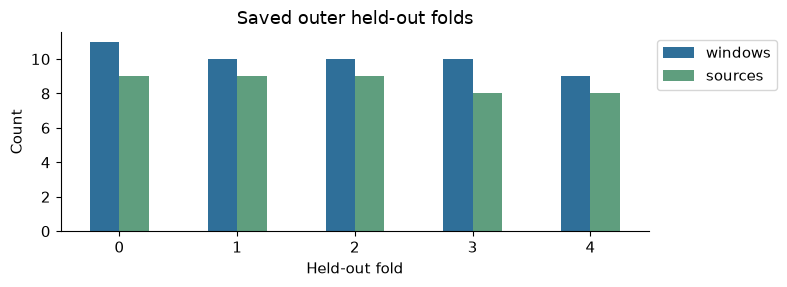

In [3]:
if MODE == "teach":
    from gavd6_sjepa.research_directions.future_innovation.fi_cohort import assign_source_folds, validate_cohort
    sources = [f"generated-source-{i // 2:02d}" for i in range(50)]
    fold_for = assign_source_folds(sources)
    cohort = pd.DataFrame({"window_id": [f"generated-window-{i}" for i in range(50)],
                           "video_id": sources, "outer_fold": [fold_for[s] for s in sources]})
    validate_cohort(cohort)
else:
    cohort = read_optional_table(RUN_ROOT, "manifests/gate-windows.csv")
if cohort is not None:
    census = cohort.groupby("outer_fold").agg(windows=("window_id", "size"),
                                              sources=("video_id", "nunique"))
    display(census)
    assert cohort.groupby("video_id").outer_fold.nunique().max() == 1
    ax = census.plot.bar(color=["#2f6f99", "#5f9e7e"], rot=0,
                         title="Generated outer held-out folds" if MODE == "teach" else "Saved outer held-out folds")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set(xlabel="Held-out fold", ylabel="Count")
    plt.tight_layout(); plt.show()
else:
    print("No frozen cohort manifest in this local copy. No census is inferred from images alone.")

## 2. Put the observation boundary on one timeline

Frames are zero-based after annotation conversion. Frames 0–31 supply
the inputs; the target spans 38–39 and ends eight frames after the last
observed frame. The teacher target uses the full 64-frame clip and can
therefore include information after frame 39. Its interpretation is a
full-clip contextual feature at that location.

The timeline reads the production `FRAME` contract, keeping the displayed
boundary tied to the implementation. The physical horizon in seconds
depends on the source frame rate.

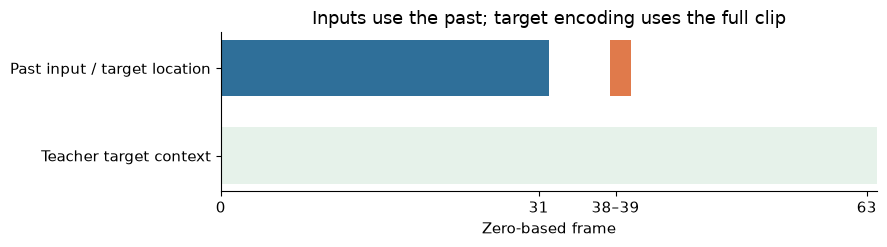

In [4]:
from gavd6_sjepa.research_directions.future_innovation.fi_contracts import FRAME
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.broken_barh([(0, FRAME.context_stop_exclusive)], (1, 0.65), facecolors="#2f6f99")
ax.broken_barh([(FRAME.target_tubelet_start, FRAME.tubelet_size)], (1, 0.65), facecolors="#e07a4b")
ax.broken_barh([(0, FRAME.frames_per_clip)], (0, 0.65), facecolors="#e6f2ea")
ax.set(yticks=[0.325, 1.325], yticklabels=["Teacher target context", "Past input / target location"],
       xticks=[0, 31, 38.5, 63], xticklabels=["0", "31", "38–39", "63"],
       xlabel="Zero-based frame", xlim=(0, 64))
ax.set_title("Inputs use the past; target encoding uses the full clip")
plt.tight_layout(); plt.show()

## 3. Inspect exclusions before interpreting model scores

A usable row needs exact decoding, aligned boxes, a nonempty person
token region and at least one observed joint transition. Natural missingness stays explicit through
confidence and validity channels. The pipeline saves every exclusion and
an alignment overlay for each accepted window.

Exclusion counts can reveal a narrow selected cohort. An overlay can
reveal a misplaced crop; it does not certify timing, source separation,
or teacher validity. Read the manifests as well as the pictures.

### How to read the common exclusion reasons

- **Sequence shorter than 64 frames** means the sequence's inclusive
  `first_frame`–`last_frame` span contains fewer than 64 frames. The
  pipeline must choose one contiguous 64-frame window (frames 0–63 in
  the clip contract), so this sequence cannot supply a valid window.
  This is a length check, not a claim that an individual annotation is
  invalid.
- **Source video not cached** in an older run describes the old
  `youtube/all/<video_id>` lookup, not all storage on HAIC. New runs
  resolve explicit full-source paths in the video manifest, then exact
  source IDs throughout the configured storage directories. Add other
  directories through `FI_VIDEO_ROOTS` before initialization. Ambiguous
  exports require an explicit manifest `video_path`; clips with reset
  frame numbering are not substitutes for full source videos.
- **Cohort cap** means 50 usable clips have already been selected;
  **source cap** limits each source to two clips. Neither indicates a
  missing or low-quality video. Candidates after the cap are not pose
  evaluated, and no quality finding can be inferred for those clips.

Existing cohorts retain their original candidate/exclusion records on
resume. To apply new discovery or window-selection rules, initialize a
new run directory; never silently replace a cohort behind cached features.

,outcome,stage,reason,sequences
0,Eligibility failure,candidate,Sequence shorter than 64 frames,145
1,Eligibility failure,candidate,Source video not found in declared storage: 5q...,8
2,Eligibility failure,candidate,Source video not found in declared storage: 7x...,1
3,Eligibility failure,candidate,Source video not found in declared storage: Iu...,2
4,Eligibility failure,candidate,Source video not found in declared storage: JS...,2
5,Eligibility failure,candidate,Source video not found in declared storage: XY...,3
6,Eligibility failure,candidate,Source video not found in declared storage: Yj...,1
7,Eligibility failure,candidate,Source video not found in declared storage: gO...,2
8,Eligibility failure,candidate,Source video not found in declared storage: gX...,1
9,Eligibility failure,candidate,Source video not found in declared storage: gp...,1


,sequence_id,stage,reason
0,cll7qvutf008d3o6lwsz9gxtf,candidate,Sequence shorter than 64 frames
1,cll8lc6c0000e3o6lgu3uicr8,candidate,Source video not found in declared storage: sf...
2,cljxjrak3000p3n6lpocul02a,candidate,Sequence shorter than 64 frames
3,cll4sqvdl00383o6lhsd4an2j,candidate,Sequence shorter than 64 frames
4,cljapw5z9007o3n6lx3gdpodt,candidate,Source video not found in declared storage: jz...
5,cljapigcs005t3n6lrszkuyo2,candidate,Source video not found in declared storage: jz...
6,cljxhybys00583n6l77dunspa,candidate,Sequence shorter than 64 frames
7,cll7quy7y00893o6lgq17f5xp,candidate,Sequence shorter than 64 frames
8,cljapl0g800653n6lqbg2u3dy,candidate,Source video not found in declared storage: jz...
9,cljapkbp500613n6lnp0i73x0,candidate,Source video not found in declared storage: jz...


214 eligibility failures; 1610 not selected by cohort size/source cap.


,available,method,source videos
0,False,missing,14
1,True,exact source ID,334


,video_id,available,video_path,method,reason
37,5qM6wxZ_dNs,False,NaN,missing,Source video not found in declared storage: 5q...
47,7xcj-byGS4w,False,NaN,missing,Source video not found in declared storage: 7x...
105,IuEeKzqsfmk,False,NaN,missing,Source video not found in declared storage: Iu...
110,JSyLnt3rLxs,False,NaN,missing,Source video not found in declared storage: JS...
180,XYw9gQkQv_Y,False,NaN,missing,Source video not found in declared storage: XY...
187,YjRoLtP1di0,False,NaN,missing,Source video not found in declared storage: Yj...
241,gOMr8ezwiSU,False,NaN,missing,Source video not found in declared storage: gO...
243,gXws-A4op-E,False,NaN,missing,Source video not found in declared storage: gX...
245,gpNLTB58kK0,False,NaN,missing,Source video not found in declared storage: gp...
261,jzkn287X-84,False,NaN,missing,Source video not found in declared storage: jz...


50 local overlays. Their presence alone does not establish a completed cohort.


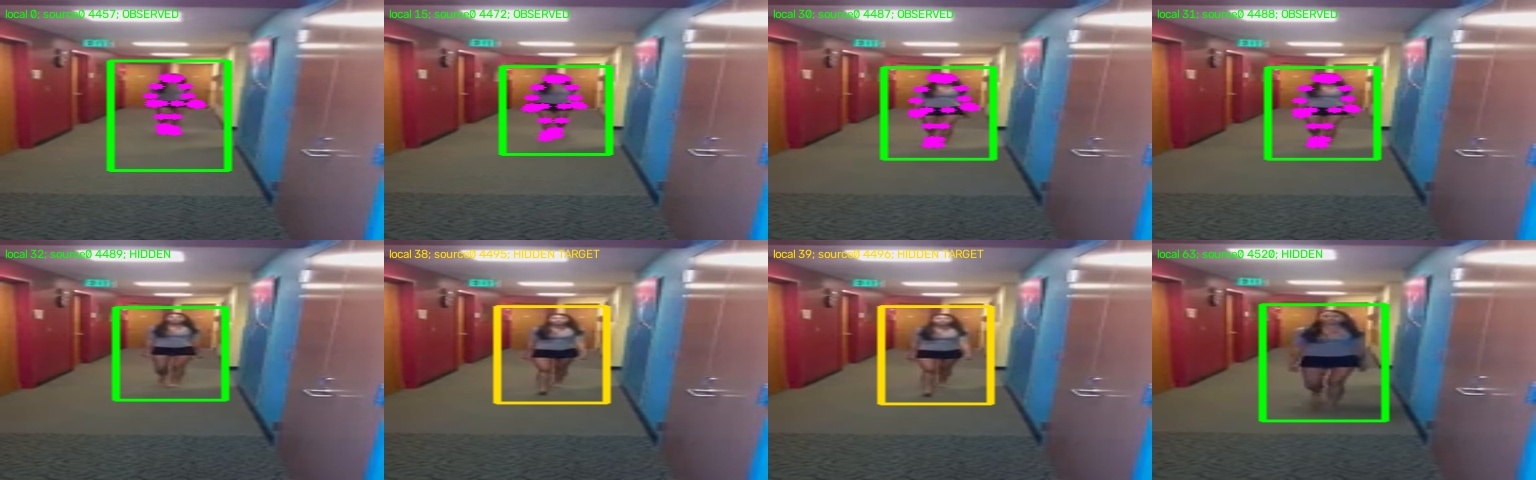

,stage,record,present_locally
0,Setup,config/run-contract.json,True
1,Candidates,config/candidates-contract.json,True
2,Aligned cohort,config/cohort-contract.json,True


In [5]:
if MODE != "teach":
    exclusions = read_optional_table(RUN_ROOT, "manifests/exclusions.csv")
    if exclusions is not None:
        summary = exclusions.groupby(["stage", "reason"]).size().rename("sequences").reset_index()
        summary["outcome"] = np.where(summary.stage == "selection", "Not selected", "Eligibility failure")
        display(summary[["outcome", "stage", "reason", "sequences"]])
        failures = exclusions[exclusions.stage != "selection"]
        display(failures.head(10))
        print(f"{len(failures)} eligibility failures; {len(exclusions) - len(failures)} not selected by cohort size/source cap.")
    availability = read_optional_table(RUN_ROOT, "manifests/source-availability.csv")
    if availability is not None:
        display(availability.groupby(["available", "method"]).size().rename("source videos").reset_index())
        display(availability[availability.video_path.fillna("") == ""].head(10))
    else:
        print("No source-discovery inventory in this older run. Its exclusions describe the original lookup.")
    overlays = sorted((RUN_ROOT / "qc/alignment-overlays").glob("*.jpg"))
    print(f"{len(overlays)} local overlays. Their presence alone does not establish a completed cohort.")
    if overlays:
        from IPython.display import Image
        display(Image(filename=str(overlays[0]), width=720))
    display(artifact_inventory(RUN_ROOT).iloc[:3])

In [6]:
if MODE == "execute":
    require_stage_success(stage_error)

## What this step establishes

In teaching mode the census is generated; in execution and inspection it describes the saved cohort. Examine exclusions and alignment alongside source counts. Missing manifests or inconsistent source assignments must be resolved before fitting. Next we test the teacher's observation boundary.

Continue with [02_teacher_features_and_validity.ipynb](02_teacher_features_and_validity.ipynb).

In [7]:
print(f"Notebook elapsed time: {perf_counter() - started:.2f} seconds ({MODE} mode).")

Notebook elapsed time: 120.68 seconds (execute mode).
